### Imports

In [1]:
import torch
from torch.utils.data import DataLoader
from torchvision import transforms
import torch.nn as nn
import os
from pathlib import Path
import sys
import matplotlib.pyplot as plt
import numpy as np

In [2]:
PROJECT_ROOT = Path.cwd().parent

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

In [52]:
from training.datasets import (
    get_indices, 
    get_class_labels, 
    calculate_transformation_params, 
    MyDataset,
    worker_init_fn,
    )
from training.train import train_one_epoch, train_model
from training.evaluation import evaluate_model, calculate_metrics, confusion_matrix
from training.predict import get_predictions
from models.ResNet18 import ResNet18
from models.CNN import CNN

In [4]:
# Reproducibility
SEED = 42

torch.manual_seed(SEED)

# Device
device = torch.device(
    "mps" if torch.backends.mps.is_available() else "cpu"
)

print(f"Using device: {device}")

# Training configuration
BATCH_SIZE = 64
NUM_EPOCHS = 30

LEARNING_RATE = 1e-5
LEARNING_RATE2 = 5e-4

PATIENCE = 5
MIN_DELTA = 1e-3

# Dataset
NUM_CLASSES = 6
N_IMAGES = 1_000

NUM_WORKERS = 2

Using device: mps


### Get data files for the model

In [5]:
files_dir = Path(PROJECT_ROOT, r'output/modes')
os.chdir(files_dir)

files = os.listdir()
files = [file for file in files if file[-3:]=='.h5']
for elem in files:
    elem = Path(files_dir, elem)

Train, test, and validation ratios

In [6]:
train_ratio = 0.75
validation_ratio = 0.15

Generate datasets

In [7]:
indices_train, indices_test, indices_validate = [], [], []

for file in files:
    temp1, temp2, temp3 = get_indices((train_ratio, validation_ratio),N=N_IMAGES)
    indices_train.append(temp1)
    indices_test.append(temp2)
    indices_validate.append(temp3)

In [8]:
classes_train, classes_test, classes_val = get_class_labels(indices_train, indices_test, indices_validate)

Training data transformation

In [9]:
tr_mean, tr_std = calculate_transformation_params(
    files, 
    indices_train, 
    # Adjust to your memory capabilities
    n_subset=1024
)

Transformation for train dataset

In [10]:
transform = transforms.Normalize(
    mean=(tr_mean,),
    std=(tr_std,)
)

Define datasets

In [11]:
train_dataset = MyDataset(
    files=files,
    indices=indices_train,
    transform=transform
)

validate_dataset = MyDataset(
    files=files,
    indices=indices_validate,
    transform=transform
)

test_dataset = MyDataset(
    files=files,
    indices=indices_test,
    transform=transform
)

Dataset loaders

In [12]:
train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=NUM_WORKERS,
    worker_init_fn=worker_init_fn,
)

validation_loader = DataLoader(
    validate_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    worker_init_fn=worker_init_fn,
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    worker_init_fn=worker_init_fn,
)

### ResNet18

Create model

In [13]:
model = ResNet18(num_classes=6)
model.to(device)

num_parameters = sum(
    p.numel()
    for p in model.parameters()
    if p.requires_grad
)

print(f"Trainable parameters: {num_parameters:,}")

Trainable parameters: 11,173,318


In [14]:
criterion = nn.CrossEntropyLoss()

In [15]:
optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=LEARNING_RATE,
    weight_decay=1e-4,
)

Train model

In [16]:
model, history = train_model(
    model=model,
    train_loader=train_loader,
    validation_loader=validation_loader,
    criterion=criterion,
    optimizer=optimizer,
    device=device,
    num_epochs=NUM_EPOCHS,
    num_classes=NUM_CLASSES,
    patience=PATIENCE,
    min_delta=MIN_DELTA,
)

Epoch 1/30 | train loss: 1.0132 | val loss: 0.7210 | time: 2 min 47.9 s
Metrics: Accuracy: 0.7633 | Precision: 0.8314 | Recall: 0.7633 | F1-score: 0.7677 | AUROC: 0.9819
Epoch 2/30 | train loss: 0.4506 | val loss: 0.3970 | time: 3 min 7.4 s
Metrics: Accuracy: 0.8656 | Precision: 0.8834 | Recall: 0.8656 | F1-score: 0.8628 | AUROC: 0.9940
Epoch 3/30 | train loss: 0.2115 | val loss: 0.1097 | time: 15 min 15.3 s
Metrics: Accuracy: 0.9800 | Precision: 0.9819 | Recall: 0.9800 | F1-score: 0.9799 | AUROC: 1.0000
Epoch 4/30 | train loss: 0.0818 | val loss: 0.0390 | time: 2 min 54.1 s
Metrics: Accuracy: 0.9978 | Precision: 0.9978 | Recall: 0.9978 | F1-score: 0.9978 | AUROC: 1.0000
Epoch 5/30 | train loss: 0.0426 | val loss: 0.0190 | time: 3 min 29.0 s
Metrics: Accuracy: 1.0000 | Precision: 1.0000 | Recall: 1.0000 | F1-score: 1.0000 | AUROC: 1.0000
Epoch 6/30 | train loss: 0.0300 | val loss: 0.0205 | time: 2 min 48.4 s
Metrics: Accuracy: 0.9989 | Precision: 0.9989 | Recall: 0.9989 | F1-score: 0.9

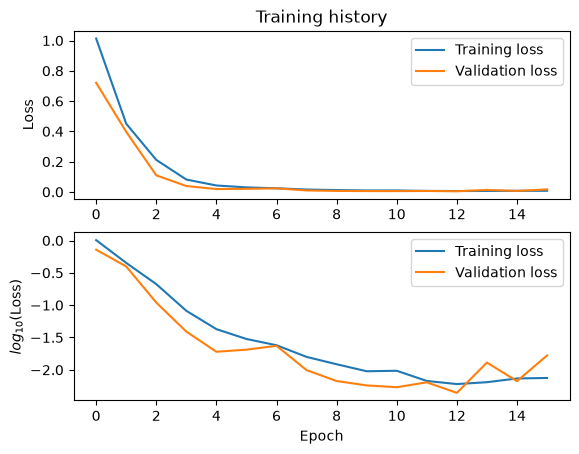

In [17]:
plt.subplots(2, 1)

plt.subplot(2, 1, 1)
plt.plot(history["train_loss"], label="Training loss")
plt.plot(history["validation_loss"], label="Validation loss")
plt.ylabel("Loss")
plt.title("Training history")
plt.legend()

plt.subplot(2, 1, 2)
plt.plot(np.log10(history["train_loss"]), label="Training loss")
plt.plot(np.log10(history["validation_loss"]), label="Validation loss")
plt.xlabel("Epoch")
plt.ylabel("$log_{10}$(Loss)")
plt.legend()

plt.tight_layout
plt.show()

Model evaluation

In [18]:
val_loss, val_labels, val_predictions, val_probabilities = evaluate_model(
    model=model,
    loader=validation_loader,
    criterion=criterion,
    device=device,
)

In [19]:
val_metrics = calculate_metrics(
    predictions=val_predictions,
    probabilities=val_probabilities,
    target=val_labels,
    num_classes=NUM_CLASSES,
)

In [20]:
for name, value in val_metrics.items():
    print(f"{name}: {value.item():.4f}")

accuracy: 1.0000
precision: 1.0000
recall: 1.0000
f1: 1.0000
auroc: 1.0000


In [21]:
val_confusion_matrix = confusion_matrix(
    target=val_labels,
    predictions=val_predictions,
    num_classes=NUM_CLASSES,
)

print(val_confusion_matrix)

tensor([[150,   0,   0,   0,   0,   0],
        [  0, 150,   0,   0,   0,   0],
        [  0,   0, 150,   0,   0,   0],
        [  0,   0,   0, 150,   0,   0],
        [  0,   0,   0,   0, 150,   0],
        [  0,   0,   0,   0,   0, 150]])


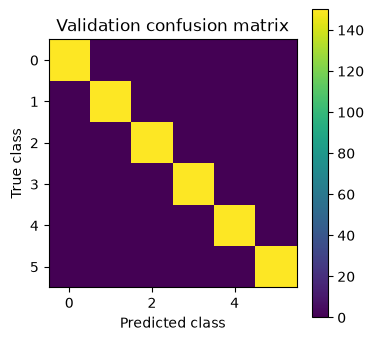

In [22]:
plt.figure(figsize=(4, 4))

plt.imshow(
    val_confusion_matrix.numpy()
)

plt.xlabel("Predicted class")
plt.ylabel("True class")
plt.title("Validation confusion matrix")

plt.colorbar()

plt.show()

Testing model on unknown data

In [23]:
test_loss, test_labels, test_predictions, test_probabilities = evaluate_model(
    model=model,
    loader=test_loader,
    criterion=criterion,
    device=device,
)

In [24]:
test_metrics = calculate_metrics(
    predictions=test_predictions,
    probabilities=test_probabilities,
    target=test_labels,
    num_classes=NUM_CLASSES,
)

for name, value in test_metrics.items():
    print(f"{name}: {value.item():.4f}")

accuracy: 1.0000
precision: 1.0000
recall: 1.0000
f1: 1.0000
auroc: 1.0000


In [25]:
test_confusion_matrix = confusion_matrix(
    target=test_labels,
    predictions=test_predictions,
    num_classes=NUM_CLASSES,
)

print(test_confusion_matrix)

tensor([[100,   0,   0,   0,   0,   0],
        [  0, 100,   0,   0,   0,   0],
        [  0,   0, 100,   0,   0,   0],
        [  0,   0,   0, 100,   0,   0],
        [  0,   0,   0,   0, 100,   0],
        [  0,   0,   0,   0,   0, 100]])


__Conclusions__

The results show that the classification of individual Laguerre–Gaussian modes is a relatively simple and well-separable task for a CNN. ResNet18 achieved 99.5% validation accuracy after only four epochs and 100% accuracy after five epochs. Perfect classification was also obtained on the test set, with diagonal confusion matrices.

These results indicate that the network learned the characteristic spatial intensity patterns of the individual LG modes rather than simply memorizing the training images. Since the beam size, position, power, and sensor noise were varied during data generation, the model demonstrated good generalization within the considered data distribution.

The results also suggest that a significantly simpler CNN architecture may be sufficient for reliable classification of individual LG modes.

Saving the best model

In [26]:
torch.save(
    {
        "model_state_dict": model.state_dict(),
        "optimizer_state_dict": optimizer.state_dict(),
        "num_classes": NUM_CLASSES,
        "learning_rate": LEARNING_RATE,
        "history": history,
    },

    "best_model_ResNet18.pt",
)

### CNN model

In [53]:
model2 = CNN(n_classes=6)
model2.to(device)

num_parameters = sum(
    p.numel()
    for p in model2.parameters()
    if p.requires_grad
)

print(f"Trainable parameters: {num_parameters:,}")

Trainable parameters: 97,926


In [54]:
optimizer2 = torch.optim.AdamW(
    model2.parameters(),
    lr=LEARNING_RATE2,
    weight_decay=1e-4,
)

In [55]:
model2, history2 = train_model(
    model=model2,
    train_loader=train_loader,
    validation_loader=validation_loader,
    criterion=criterion,
    optimizer=optimizer2,
    device=device,
    num_epochs=NUM_EPOCHS,
    num_classes=NUM_CLASSES,
    patience=PATIENCE,
    min_delta=MIN_DELTA,
)

python(30434) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
python(30435) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
python(30457) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
python(30458) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.


Epoch 1/30 | train loss: 1.6134 | val loss: 1.3413 | time: 0 min 53.5 s
Metrics: Accuracy: 0.4122 | Precision: 0.3695 | Recall: 0.4122 | F1-score: 0.3680 | AUROC: 0.8160


python(30464) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
python(30465) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
python(30471) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
python(30472) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.


Epoch 2/30 | train loss: 1.2351 | val loss: 1.0995 | time: 0 min 43.0 s
Metrics: Accuracy: 0.5178 | Precision: 0.5239 | Recall: 0.5178 | F1-score: 0.5112 | AUROC: 0.8778


python(30503) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
python(30504) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
python(30517) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
python(30518) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.


...

Epoch 28/30 | train loss: 0.1413 | val loss: 0.1177 | time: 0 min 42.2 s
Metrics: Accuracy: 0.9667 | Precision: 0.9696 | Recall: 0.9667 | F1-score: 0.9663 | AUROC: 0.9987


python(31466) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
python(31467) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
python(31497) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
python(31498) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.


Epoch 29/30 | train loss: 0.1274 | val loss: 0.1061 | time: 0 min 42.8 s
Metrics: Accuracy: 0.9733 | Precision: 0.9740 | Recall: 0.9733 | F1-score: 0.9734 | AUROC: 0.9987


python(31509) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
python(31510) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
python(31527) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
python(31528) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.


Epoch 30/30 | train loss: 0.1446 | val loss: 0.1478 | time: 0 min 42.5 s
Metrics: Accuracy: 0.9378 | Precision: 0.9447 | Recall: 0.9378 | F1-score: 0.9368 | AUROC: 0.9986


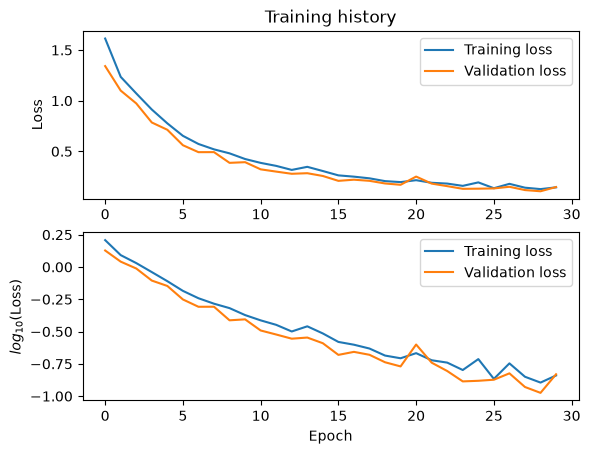

In [56]:
plt.subplots(2, 1)

plt.subplot(2, 1, 1)
plt.plot(history2["train_loss"], label="Training loss")
plt.plot(history2["validation_loss"], label="Validation loss")
plt.ylabel("Loss")
plt.title("Training history")
plt.legend()

plt.subplot(2, 1, 2)
plt.plot(np.log10(history2["train_loss"]), label="Training loss")
plt.plot(np.log10(history2["validation_loss"]), label="Validation loss")
plt.xlabel("Epoch")
plt.ylabel("$log_{10}$(Loss)")
plt.legend()

plt.tight_layout
plt.show()

In [65]:
val_loss2, val_labels2, val_predictions2, val_probabilities2 = evaluate_model(
    model=model2,
    loader=validation_loader,
    criterion=criterion,
    device=device,
)

python(31781) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
python(31782) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.


In [66]:
val_metrics2 = calculate_metrics(
    predictions=val_predictions2,
    probabilities=val_probabilities2,
    target=val_labels2,
    num_classes=NUM_CLASSES,
)

for name, value in val_metrics2.items():
    print(f"{name}: {value.item():.4f}")

accuracy: 0.9733
precision: 0.9740
recall: 0.9733
f1: 0.9734
auroc: 0.9987


In [67]:
val_confusion_matrix2 = confusion_matrix(
    target=val_labels2,
    predictions=val_predictions2,
    num_classes=NUM_CLASSES,
)

print(val_confusion_matrix2)

tensor([[144,   6,   0,   0,   0,   0],
        [  3, 142,   5,   0,   0,   0],
        [  0,   0, 149,   1,   0,   0],
        [  0,   0,   0, 150,   0,   0],
        [  0,   1,   5,   0, 144,   0],
        [  0,   0,   0,   3,   0, 147]])


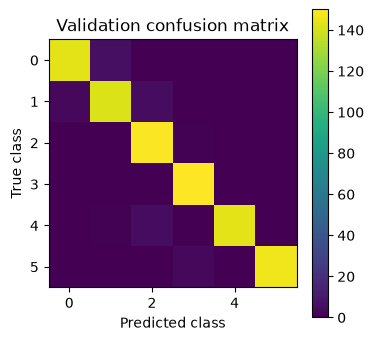

In [68]:
plt.figure(figsize=(4, 4))

plt.imshow(
    val_confusion_matrix2.numpy()
)

plt.xlabel("Predicted class")
plt.ylabel("True class")
plt.title("Validation confusion matrix")

plt.colorbar()

plt.show()

Testing model on unknown data

In [69]:
test_loss2, test_labels2, test_predictions2, test_probabilities2 = evaluate_model(
    model=model2,
    loader=test_loader,
    criterion=criterion,
    device=device,
)

python(31791) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
python(31792) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.


In [70]:
test_metrics2 = calculate_metrics(
    predictions=test_predictions2,
    probabilities=test_probabilities2,
    target=test_labels2,
    num_classes=NUM_CLASSES,
)

for name, value in test_metrics2.items():
    print(f"{name}: {value.item():.4f}")

accuracy: 0.9667
precision: 0.9682
recall: 0.9667
f1: 0.9665
auroc: 0.9983


In [71]:
test_confusion_matrix2 = confusion_matrix(
    target=test_labels2,
    predictions=test_predictions2,
    num_classes=NUM_CLASSES,
)

print(test_confusion_matrix2)

tensor([[ 99,   1,   0,   0,   0,   0],
        [  4,  90,   6,   0,   0,   0],
        [  0,   0, 100,   0,   0,   0],
        [  0,   0,   0, 100,   0,   0],
        [  0,   4,   5,   0,  91,   0],
        [  0,   0,   0,   0,   0, 100]])


__Conclusions__

The results show that the classification of individual Laguerre–Gaussian modes is a well-separable task for a CNN. The proposed CNN achieved a validation accuracy of up to 97.3% and an AUROC of approximately 0.999, while reaching about 96.7% accuracy on the independent test set. The confusion matrices show that most samples were classified correctly, with the majority of errors occurring between the most visually similar modes. These results suggest that the network learned characteristic spatial intensity patterns of the LG modes and generalized well to previously unseen samples within the considered data distribution. Despite its simpler architecture compared with ResNet18, the CNN achieved high classification performance, indicating that a lightweight, task-specific architecture may be sufficient for reliable LG mode classification.

Saving the best model

In [72]:
torch.save(
    {
        "model_state_dict": model2.state_dict(),
        "optimizer_state_dict": optimizer2.state_dict(),
        "num_classes": NUM_CLASSES,
        "learning_rate": LEARNING_RATE2,
        "history": history2,
    },

    "best_model_CNN.pt",
)